In [1]:
! pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 64.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.8/733.8 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.3/95.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: importlib_metadata
    Found existing installation: importlib_metadata 8.7.0
    Uninstalling importlib_metadata-8.7.0:
      Successfully uninstalled importlib_metadata-8.7.0
ERROR: pip's dependency resolver does not currently take into account all the p

In [3]:
! pip install ultralytics

In [1]:
## importation des packages

import os
import random
import shutil
#import mlflow
%matplotlib inline
import matplotlib.pyplot as plt
#from ultralytics import YOLO
import cv2
import glob
import random
import glob

In [2]:
import os
import shutil
import random

# Paramètres
images_dir = "data_pant_annotation/images"
labels_dir = "data_pant_annotation/labels"
train_ratio = 0.8

# Créer les sous-dossiers train et val dans images et labels
for subset in ["train", "val"]:
    os.makedirs(os.path.join(images_dir, subset), exist_ok=True)
    os.makedirs(os.path.join(labels_dir, subset), exist_ok=True)

# Récupérer la liste des fichiers images
image_files = [f for f in os.listdir(images_dir) if f.lower().endswith('.png') and os.path.isfile(os.path.join(images_dir, f))]

# Mélanger
random.shuffle(image_files)

# Split
split_idx = int(len(image_files) * train_ratio)
train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

# Fonction pour déplacer images et labels
def move_files(file_list, subset):
    for filename in file_list:
        image_src = os.path.join(images_dir, filename)
        label_src = os.path.join(labels_dir, os.path.splitext(filename)[0] + ".txt")
        
        image_dst = os.path.join(images_dir, subset, filename)
        label_dst = os.path.join(labels_dir, subset, os.path.splitext(filename)[0] + ".txt")
        
        shutil.move(image_src, image_dst)
        
        if os.path.exists(label_src):
            shutil.move(label_src, label_dst)
        else:
            print(f"⚠️ Label manquant pour {filename}")

# Déplacer les fichiers
move_files(train_files, "train")
move_files(val_files, "val")

print("✅ Répartition terminée.")


✅ Répartition terminée.


# Test Yolov11

In [1]:
import torch

print(torch.__version__)        # Affiche la version PyTorch
print(torch.version.cuda)       # Affiche la version CUDA avec laquelle PyTorch a été compilé (ou None)
print(torch.cuda.is_available())# True si un GPU compatible CUDA est détecté et utilisable
print(torch.cuda.device_count())# Nombre de GPU CUDA disponibles
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0)) # Nom du premier GPU CUDA détecté


2.7.1+cu118
11.8
True
1
NVIDIA RTX A5000


In [1]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
model = YOLO("yolo11n.pt")

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="data_pant_annotation/data.yaml", epochs=10, imgsz=640)

# Run inference with the YOLO11n model on the 'bus.jpg' image
#results = model("path/to/bus.jpg")

Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_pant_annotation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p

train: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\train.cache... 243 images, 0 backgrounds, 0 corrupt: 100%|██████████| 243/243 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 3172.51022.2 MB/s, size: 688.3 KB)


val: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\val.cache... 61 images, 0 backgrounds, 0 corrupt: 100%|██████████| 61/61 [00:00<?, ?it/s]


Plotting labels to runs\detect\train5\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
MLflow: logging run_id(b44947a6f5484e838d04365e53edbcb5) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\train5
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      10/10      2.67G      1.601      1.327     0.9141         16        640: 100%|██████████| 16/16 [00:01<00:00, 11.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  7.44it/s]

                   all         61        390      0.885      0.704      0.699      0.379



10 epochs completed in 0.010 hours.
Optimizer stripped from runs\detect\train5\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\train5\weights\best.pt, 5.5MB

Validating runs\detect\train5\weights\best.pt...
Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  4.43it/s]


                   all         61        390      0.885      0.704      0.699      0.379
                bouton         58         92       0.95      0.935      0.983      0.561
                Rivets         52        257      0.871      0.918      0.903      0.401
 Fermeture a glissiere         36         37      0.718      0.962      0.788      0.467
                Autres          2          4          1          0      0.123     0.0859
Speed: 0.1ms preprocess, 1.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs\detect\train5
MLflow: results logged to runs\mlflow
MLflow: disable with 'yolo settings mlflow=False'



image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1295.png: 640x640 1 bouton, 4 Rivetss, 1 Fermeture a glissiere, 35.4ms
Speed: 3.8ms preprocess, 35.4ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1305.png: 640x640 1 bouton, 6 Rivetss, 1 Fermeture a glissiere, 25.5ms
Speed: 6.7ms preprocess, 25.5ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1293.png: 640x640 3 boutons, 3 Rivetss, 18.8ms
Speed: 4.2ms preprocess, 18.8ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


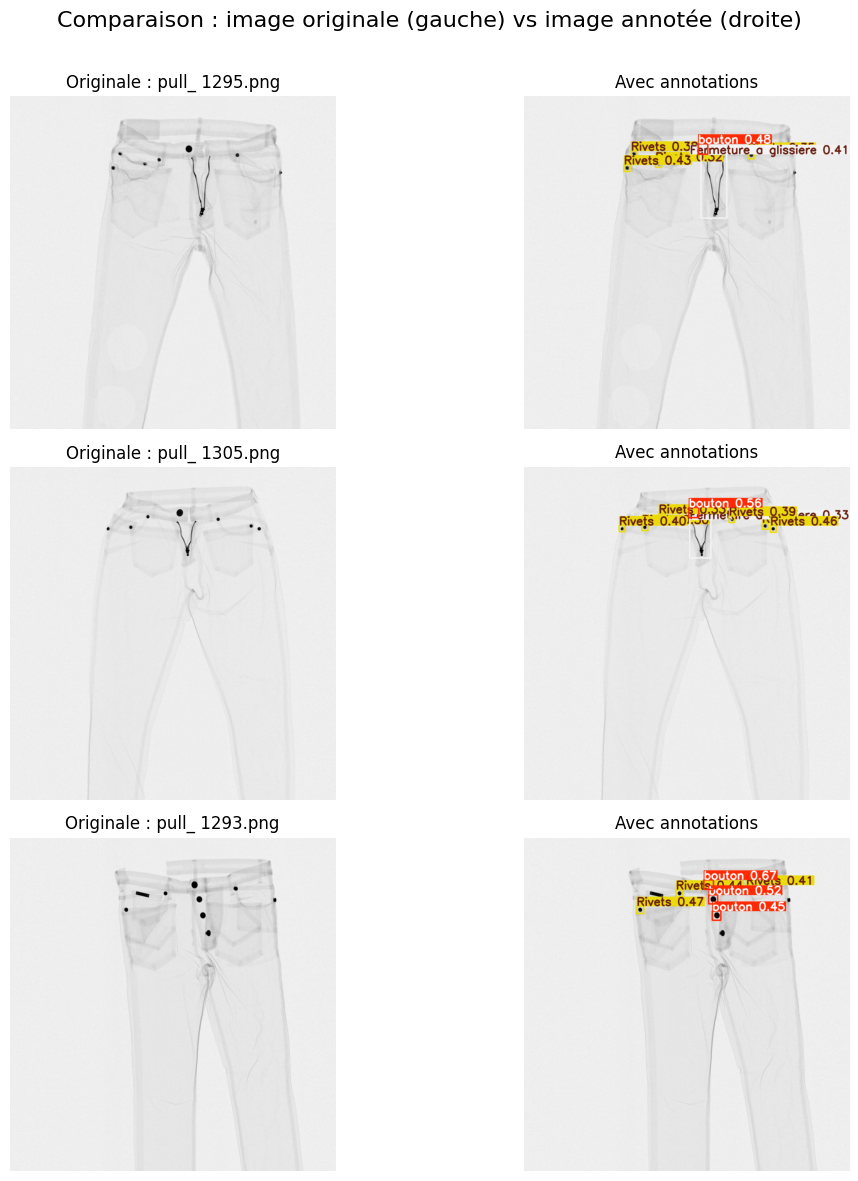

In [10]:
import glob
import os

# Charger le modèle
model_path = "runs/detect/train5/weights/best.pt"
model = YOLO(model_path)

# Récupérer les images du dossier val
val_images_folder = "Pant_test_undistorted_png_8bit"
val_images = glob.glob(os.path.join(val_images_folder, "*.png"))



# Choisir 3 images
test_images = random.sample(val_images, min(3, len(val_images)))

# Créer une figure avec 3 lignes et 2 colonnes
fig, axes = plt.subplots(len(test_images), 2, figsize=(12, 12))
fig.suptitle("Comparaison : image originale (gauche) vs image annotée (droite)", fontsize=16)

# Affichage côte à côte
for i, img_path in enumerate(test_images):
    # Image originale
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Image annotée
    results = model.predict(source=img_path, conf=0.25)[0]
    annotated_img = results.plot()

    # Colonne 1 : image originale
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Originale : {os.path.basename(img_path)}")
    axes[i, 0].axis('off')

    # Colonne 2 : image annotée
    axes[i, 1].imshow(annotated_img)
    axes[i, 1].set_title("Avec annotations")
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Laisser de l'espace pour le titre
plt.show()


# Test Yolov8

In [7]:
! yolo task=detect mode=train model=yolov8n.pt data = data_pant_annotation/data.yaml epochs=10 imgsz=640 batch=16 

Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_pant_annotation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p


  0%|          | 0.00/6.25M [00:00<?, ?B/s]
 74%|███████▍  | 4.62M/6.25M [00:00<00:00, 47.3MB/s]
100%|██████████| 6.25M/6.25M [00:00<00:00, 57.4MB/s]

train: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\train.cache... 243 images, 0 backgrounds, 0 corrupt: 100%|██████████| 243/243 [00:00<?, ?it/s]
train: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\train.cache... 243 images, 0 backgrounds, 0 corrupt: 100%|██████████| 243/243 [00:00<?, ?it/s]

val: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\val.cache... 61 images, 0 backgrounds, 0 corrupt: 100%|██████████| 61/61 [00:00<?, ?it/s]
val: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\val.cache... 61 images, 0 backgrounds, 0 corrupt: 100%|██████████| 61/61 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]
       1/10      2.01

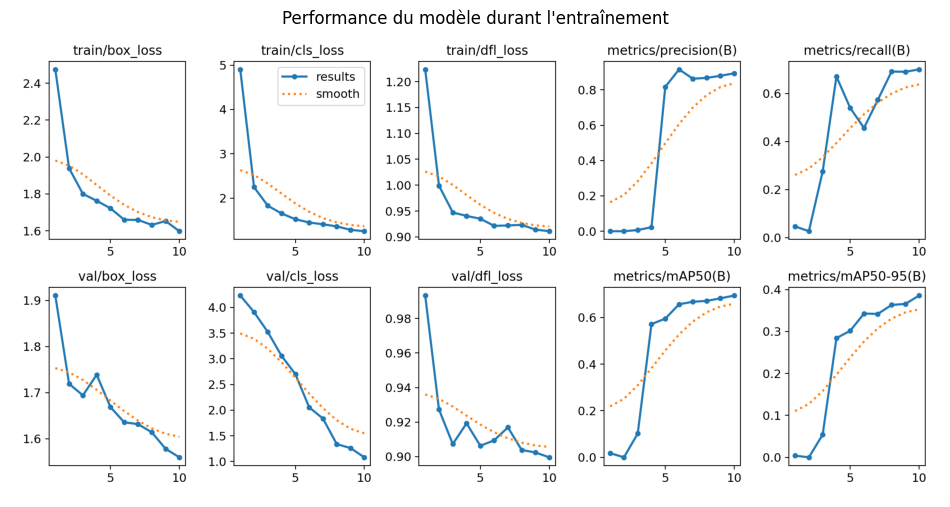

In [8]:

# 1. Affiche le graphique de performance results.png
results_img_path = "runs/detect/train6/results.png"
img = cv2.imread(results_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.title("Performance du modèle durant l'entraînement")
plt.imshow(img)
plt.axis('off')
plt.show()





image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1297.png: 640x640 1 bouton, 5 Rivetss, 1 Fermeture a glissiere, 34.3ms
Speed: 5.6ms preprocess, 34.3ms inference, 7.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1293.png: 640x640 3 boutons, 4 Rivetss, 25.4ms
Speed: 3.7ms preprocess, 25.4ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1298.png: 640x640 1 bouton, 5 Rivetss, 1 Fermeture a glissiere, 26.6ms
Speed: 3.7ms preprocess, 26.6ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


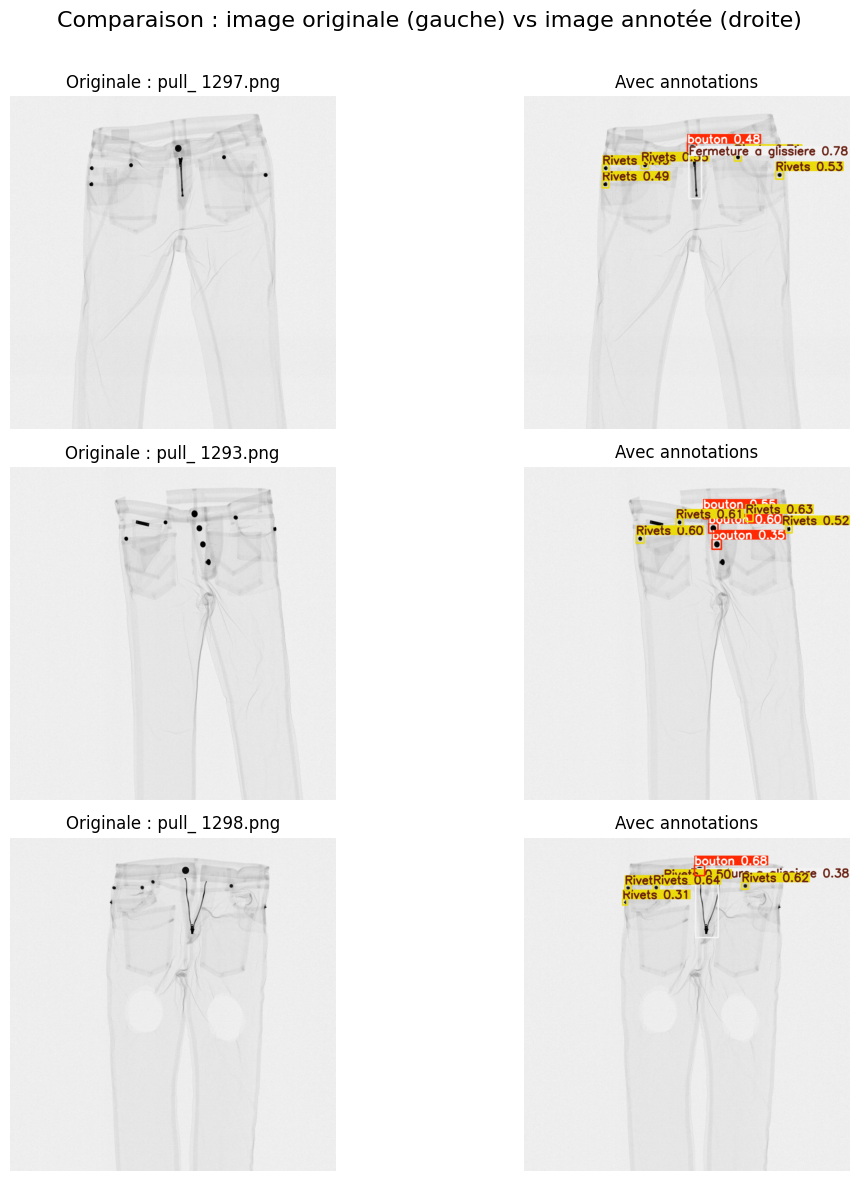

In [12]:

# Charger le modèle
model_path = "runs/detect/train6/weights/best.pt"
model = YOLO(model_path)

# Récupérer les images du dossier val
val_images_folder = "Pant_test_undistorted_png_8bit"
val_images = glob.glob(os.path.join(val_images_folder, "*.png"))



# Choisir 3 images
test_images = random.sample(val_images, min(3, len(val_images)))

# Créer une figure avec 3 lignes et 2 colonnes
fig, axes = plt.subplots(len(test_images), 2, figsize=(12, 12))
fig.suptitle("Comparaison : image originale (gauche) vs image annotée (droite)", fontsize=16)

# Affichage côte à côte
for i, img_path in enumerate(test_images):
    # Image originale
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Image annotée
    results = model.predict(source=img_path, conf=0.25)[0]
    annotated_img = results.plot()

    # Colonne 1 : image originale
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Originale : {os.path.basename(img_path)}")
    axes[i, 0].axis('off')

    # Colonne 2 : image annotée
    axes[i, 1].imshow(annotated_img)
    axes[i, 1].set_title("Avec annotations")
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Laisser de l'espace pour le titre
plt.show()


# Entrainement from Scratch

In [14]:
#!yolo task=detect mode=train model=yolov8n.yaml data=data_pant_annotation/data.yaml epochs=10 imgsz=640 batch=16 

# Load a COCO-pretrained YOLO11n model

#model = YOLO("yolo11n.pt")

model = YOLO("yolo11n.yaml")  # architecture uniquement, pas de poids


# model = YOLO("yolov8n.yaml")  # si ce fichier décrit l'archi sans poids

# Puis entraîne-le sur ton dataset from scratch
results = model.train(
    data="data_pant_annotation/data.yaml",
    epochs=10,
    imgsz=640,
    pretrained=False  # indique que tu ne veux pas utiliser de poids pré-entraînés
)

Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_pant_annotation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

train: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\train.cache... 243 images, 0 backgrounds, 0 corrupt: 100%|██████████| 243/243 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 2440.81042.5 MB/s, size: 688.3 KB)


val: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\val.cache... 61 images, 0 backgrounds, 0 corrupt: 100%|██████████| 61/61 [00:00<?, ?it/s]


Plotting labels to runs\detect\train8\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
MLflow: logging run_id(b1dba0486bf441d9af90a65cd6b58b01) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
WARNING MLflow: Failed to initialize: Changing param values is not allowed. Param with key='epochs' was already logged with value='50' for run ID='b1dba0486bf441d9af90a65cd6b58b01'. Attempted logging new value '10'.
WARNING MLflow: Not tracking this run
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\train8
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_lo

...

      10/10      2.74G      2.632      2.516      1.677         16        640: 100%|██████████| 16/16 [00:01<00:00, 12.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  7.55it/s]

                   all         61        390   0.000434    0.00953    0.00067   8.06e-05



10 epochs completed in 0.010 hours.
Optimizer stripped from runs\detect\train8\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\train8\weights\best.pt, 5.5MB

Validating runs\detect\train8\weights\best.pt...
Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  6.33it/s]


                   all         61        390   0.000379    0.00855   0.000642   7.23e-05
                bouton         58         92   0.000227     0.0109   0.000115   1.15e-05
                Rivets         52        257    0.00129     0.0233    0.00245   0.000278
 Fermeture a glissiere         36         37          0          0          0          0
                Autres          2          4          0          0          0          0
Speed: 0.1ms preprocess, 1.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs\detect\train8
MLflow: results logged to runs\mlflow
MLflow: disable with 'yolo settings mlflow=False'


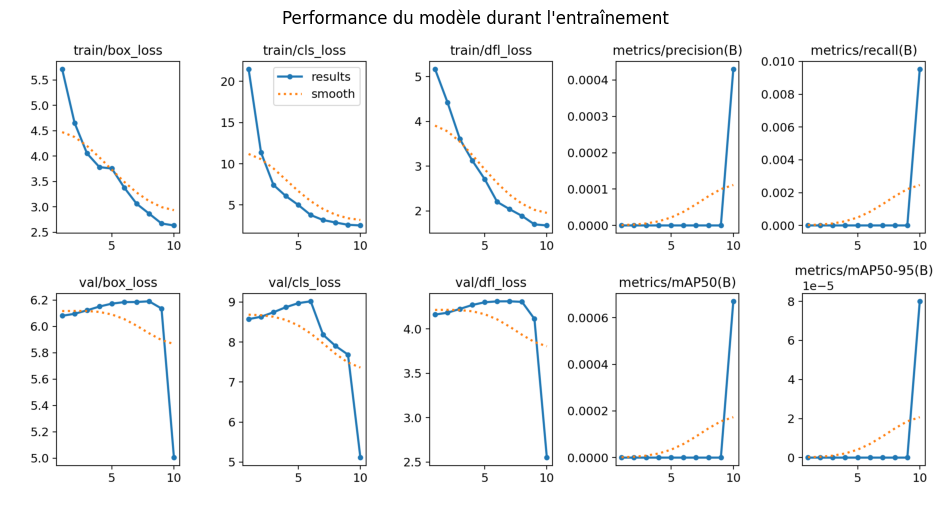

In [15]:

# 1. Affiche le graphique de performance results.png
results_img_path = "runs/detect/train8/results.png"
img = cv2.imread(results_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.title("Performance du modèle durant l'entraînement")
plt.imshow(img)
plt.axis('off')
plt.show()





image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1298.png: 640x640 (no detections), 17.1ms
Speed: 3.8ms preprocess, 17.1ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1304.png: 640x640 (no detections), 31.6ms
Speed: 3.7ms preprocess, 31.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1300.png: 640x640 (no detections), 17.4ms
Speed: 4.0ms preprocess, 17.4ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


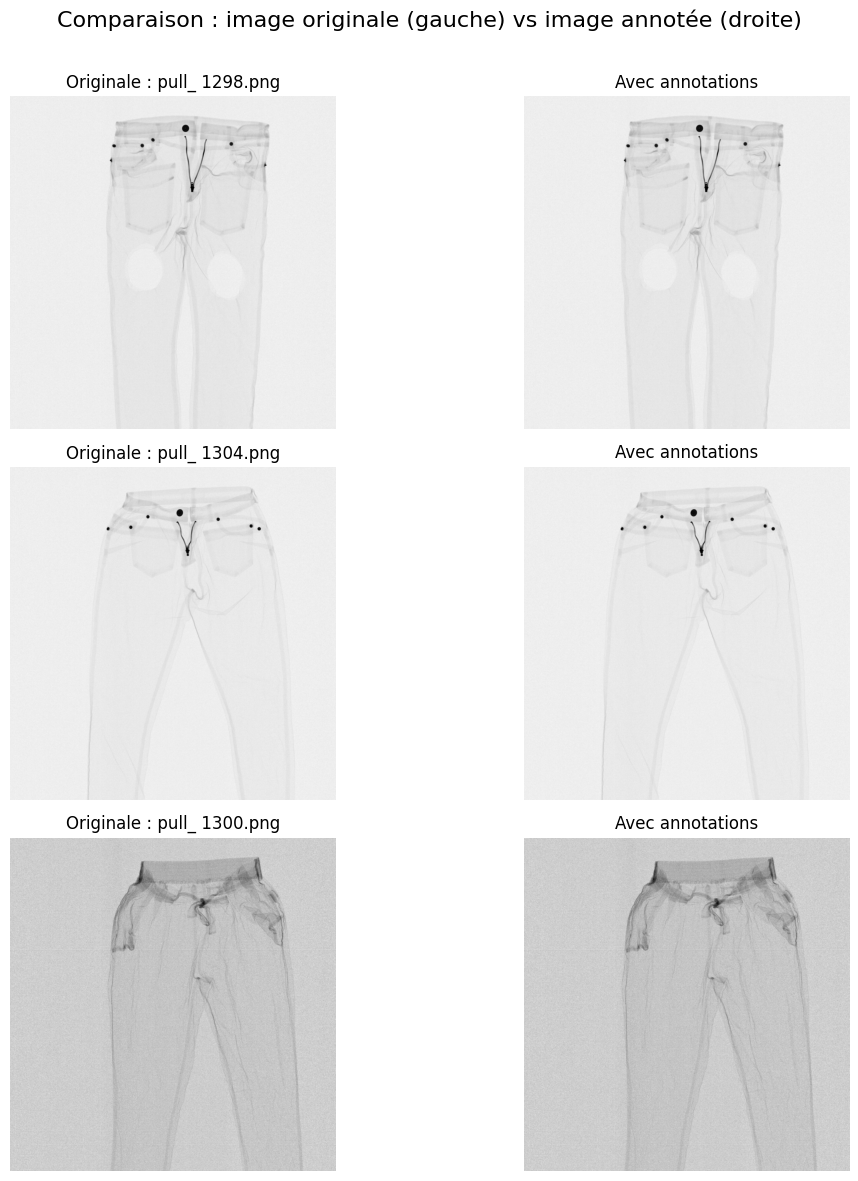

In [16]:

# Charger le modèle
model_path = "runs/detect/train8/weights/best.pt"
model = YOLO(model_path)

# Récupérer les images du dossier val
val_images_folder = "Pant_test_undistorted_png_8bit"
val_images = glob.glob(os.path.join(val_images_folder, "*.png"))



# Choisir 3 images
test_images = random.sample(val_images, min(3, len(val_images)))

# Créer une figure avec 3 lignes et 2 colonnes
fig, axes = plt.subplots(len(test_images), 2, figsize=(12, 12))
fig.suptitle("Comparaison : image originale (gauche) vs image annotée (droite)", fontsize=16)

# Affichage côte à côte
for i, img_path in enumerate(test_images):
    # Image originale
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Image annotée
    results = model.predict(source=img_path, conf=0.25)[0]
    annotated_img = results.plot()

    # Colonne 1 : image originale
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Originale : {os.path.basename(img_path)}")
    axes[i, 0].axis('off')

    # Colonne 2 : image annotée
    axes[i, 1].imshow(annotated_img)
    axes[i, 1].set_title("Avec annotations")
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Laisser de l'espace pour le titre
plt.show()


# Data Augmentation

In [21]:

# Load a COCO-pretrained YOLO11n model
model = YOLO("yolo11n.pt")

model.train(
    data='data_pant_annotation/data.yaml',
    epochs=10,
    imgsz=640,
    augment=True,       # active les augmentations par défaut
    degrees=5.0,        # rotation max
    translate=0.1,      # translation max
    scale=0.5,          # échelle min
    shear=2.0,          # cisaillement max
    flipud=0.0,         # flip vertical
    fliplr=0.2,         # flip horizontal
    mosaic=1.0,         # mosaic augmentation
    mixup=0.1,          # mixup augmentation
)


'''
degrees: 5.0      # rotation légère ±5° 
translate: 0.1    # décalage horizontal/vertical ±10%
scale: 0.5        # zoom in/out entre 0.5x et 1.5x
shear: 2.0        # cisaillement léger

# Perspective
perspective: 0.001  # désactivé (à activer uniquement si images en angle)

# Flip
flipud: 0.0       # pas de flip vertical (peu pertinent pour vêtements)
fliplr: 0.2       # flip horizontal avec 50% de probabilité

# Compositions
mosaic: 1.0       # mosaïque activée
mixup: 0.1        # mixup activé légèrement
copy_paste: 0.1   # collage d’objets modéré

# Optionnel : régularisation
label_smoothing: 0.01 '''

Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_pant_annotation/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.2, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

train: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\train.cache... 243 images, 0 backgrounds, 0 corrupt: 100%|██████████| 243/243 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 2311.0325.8 MB/s, size: 688.3 KB)


val: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\data_pant_annotation\labels\val.cache... 61 images, 0 backgrounds, 0 corrupt: 100%|██████████| 61/61 [00:00<?, ?it/s]


Plotting labels to runs\detect\train9\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
MLflow: logging run_id(574610fd49894c028331a3f17916f7bd) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\train9
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         61        390      0.892      0.703      0.686      0.364



10 epochs completed in 0.010 hours.
Optimizer stripped from runs\detect\train9\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\train9\weights\best.pt, 5.5MB

Validating runs\detect\train9\weights\best.pt...
Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.72it/s]


                   all         61        390      0.866      0.694      0.659      0.337
                bouton         58         92      0.924       0.93      0.975      0.566
                Rivets         52        257      0.821      0.875      0.894      0.375
 Fermeture a glissiere         36         37      0.717      0.973      0.766      0.407
                Autres          2          4          1          0          0          0
Speed: 0.1ms preprocess, 7.4ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs\detect\train9
MLflow: results logged to runs\mlflow
MLflow: disable with 'yolo settings mlflow=False'


'\ndegrees: 5.0      # rotation légère ±5° \ntranslate: 0.1    # décalage horizontal/vertical ±10%\nscale: 0.5        # zoom in/out entre 0.5x et 1.5x\nshear: 2.0        # cisaillement léger\n\n# Perspective\nperspective: 0.001  # désactivé (à activer uniquement si images en angle)\n\n# Flip\nflipud: 0.0       # pas de flip vertical (peu pertinent pour vêtements)\nfliplr: 0.2       # flip horizontal avec 50% de probabilité\n\n# Compositions\nmosaic: 1.0       # mosaïque activée\nmixup: 0.1        # mixup activé légèrement\ncopy_paste: 0.1   # collage d’objets modéré\n\n# Optionnel : régularisation\nlabel_smoothing: 0.01 '

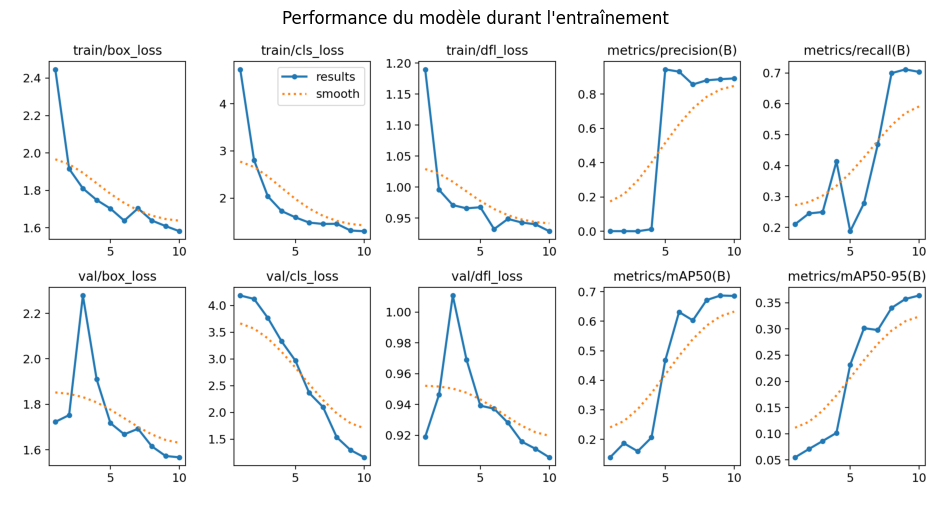

In [23]:

# 1. Affiche le graphique de performance results.png
results_img_path = "runs/detect/train9/results.png"
img = cv2.imread(results_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.title("Performance du modèle durant l'entraînement")
plt.imshow(img)
plt.axis('off')
plt.show()





image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1298.png: 640x640 1 bouton, 5 Rivetss, 1 Fermeture a glissiere, 34.4ms
Speed: 4.4ms preprocess, 34.4ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1304.png: 640x640 1 bouton, 5 Rivetss, 1 Fermeture a glissiere, 20.7ms
Speed: 3.6ms preprocess, 20.7ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1300.png: 640x640 (no detections), 26.7ms
Speed: 3.6ms preprocess, 26.7ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


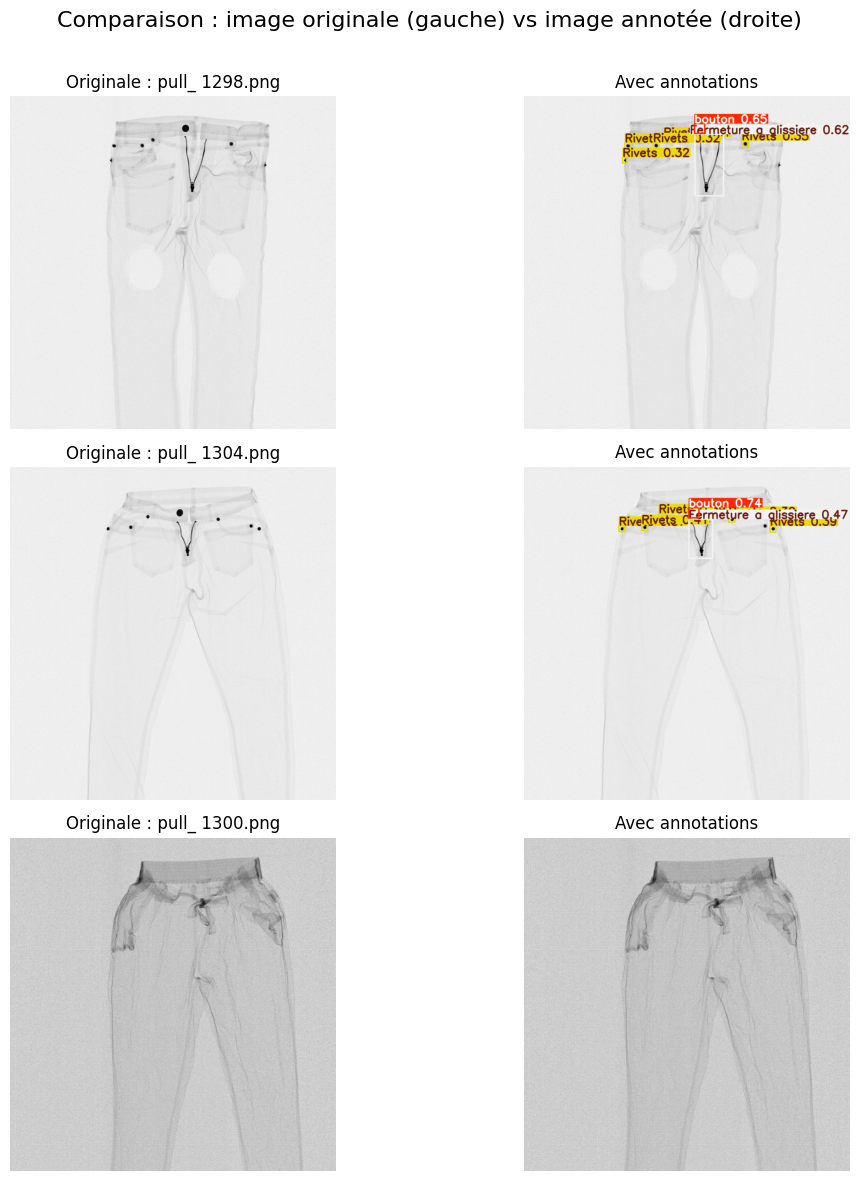

In [24]:

# Charger le modèle
model_path = "runs/detect/train9/weights/best.pt"
model = YOLO(model_path)

# Récupérer les images du dossier val
val_images_folder = "Pant_test_undistorted_png_8bit"
val_images = glob.glob(os.path.join(val_images_folder, "*.png"))



# Choisir 3 images
test_images = random.sample(val_images, min(3, len(val_images)))

# Créer une figure avec 3 lignes et 2 colonnes
fig, axes = plt.subplots(len(test_images), 2, figsize=(12, 12))
fig.suptitle("Comparaison : image originale (gauche) vs image annotée (droite)", fontsize=16)

# Affichage côte à côte
for i, img_path in enumerate(test_images):
    # Image originale
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Image annotée
    results = model.predict(source=img_path, conf=0.25)[0]
    annotated_img = results.plot()

    # Colonne 1 : image originale
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Originale : {os.path.basename(img_path)}")
    axes[i, 0].axis('off')

    # Colonne 2 : image annotée
    axes[i, 1].imshow(annotated_img)
    axes[i, 1].set_title("Avec annotations")
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Laisser de l'espace pour le titre
plt.show()


# Detection (yolo) + classification (resnet)

1 - le modele resnet est entraine a reconnaitr les points durs (en effet chaque points durs est stockees dans un dossier portant le nom en question)


2 - pour chaque image de validation choisis, le modele yolo se charge de mettre la bounding box sur le point dur 

3 - et enfin resnet predit la classe du point dur

In [3]:

# Dossiers
images_folder = 'data/images'
labels_folder = 'data/labels'
save_folder = 'cropped_dataset'

# Classes selon l'ordre YAML
class_names = ['bouton', 'Rivets', 'Fermeture a glissiere','Autres']

# Créer les dossiers de sortie
for class_name in class_names:
    os.makedirs(os.path.join(save_folder, class_name), exist_ok=True)

# Parcourir les fichiers d'images
for image_file in os.listdir(images_folder):
    if not image_file.endswith(('.png')):
        continue

    image_path = os.path.join(images_folder, image_file)
    label_file = os.path.splitext(image_file)[0] + '.txt'
    label_path = os.path.join(labels_folder, label_file)

    if not os.path.exists(label_path):
        continue

    image = cv2.imread(image_path)
    h_img, w_img = image.shape[:2]

    with open(label_path, 'r') as f:
        for idx, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])

            # Convertir coordonnées normalisées -> pixels
            x_center *= w_img
            y_center *= h_img
            width *= w_img
            height *= h_img

            x1 = int(x_center - width / 2)
            y1 = int(y_center - height / 2)
            x2 = int(x_center + width / 2)
            y2 = int(y_center + height / 2)

            # Clipping des bords
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w_img, x2), min(h_img, y2)

            roi = image[y1:y2, x1:x2]
            if roi.size == 0:
                continue

            class_name = class_names[class_id]
            save_path = os.path.join(save_folder, class_name, f"{os.path.splitext(image_file)[0]}_{idx}.jpg")
            cv2.imwrite(save_path, roi)


c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\BureauCETIA/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s] 


[1/10] Train Loss: 0.1483 | Val Loss: 0.0525
[2/10] Train Loss: 0.0739 | Val Loss: 0.0332
[3/10] Train Loss: 0.0546 | Val Loss: 0.0429
[4/10] Train Loss: 0.0237 | Val Loss: 0.0160
[5/10] Train Loss: 0.0220 | Val Loss: 0.0240
[6/10] Train Loss: 0.0491 | Val Loss: 0.0283
[7/10] Train Loss: 0.0296 | Val Loss: 0.0177
[8/10] Train Loss: 0.0198 | Val Loss: 0.0117
[9/10] Train Loss: 0.0250 | Val Loss: 0.0116
[10/10] Train Loss: 0.0205 | Val Loss: 0.0135
✅ Modèle entraîné et sauvegardé.


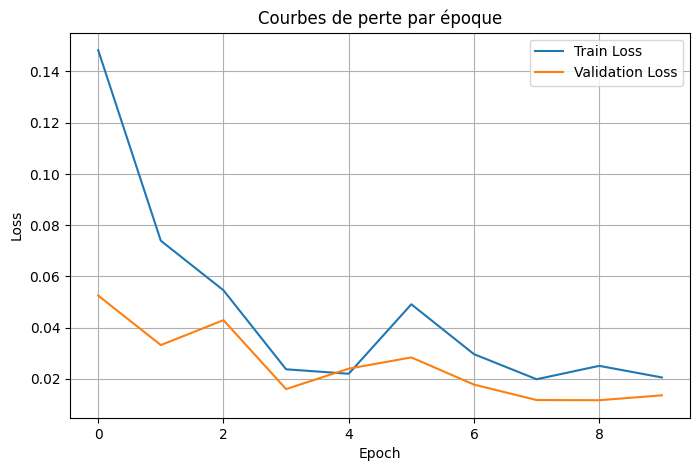

In [4]:
import os
import shutil
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.models import resnet50
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# -----------------------------
# Paramètres
# -----------------------------
data_dir = "cropped_dataset"
img_size = 512
batch_size = 16
num_epochs = 10
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# -----------------------------
# Transforms et Dataset
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

# -----------------------------
# Split train / val
# -----------------------------
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))), test_size=0.2,
    stratify=full_dataset.targets, random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# -----------------------------
# Modèle ResNet
# -----------------------------
num_classes = len(full_dataset.classes)
model = resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.to(device)

# -----------------------------
# Entraînement
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"[{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# -----------------------------
# Sauvegarde du modèle
# -----------------------------
torch.save(model.state_dict(), "resnet_pants_classifier.pth")
print("✅ Modèle entraîné et sauvegardé.")

# -----------------------------
# Courbes de perte
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbes de perte par époque')
plt.legend()
plt.grid(True)
plt.show()



Image: Pant_test_undistorted_png_8bit\pull_ 1295.png

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1295.png: 640x640 1 bouton, 4 Rivetss, 1 Fermeture a glissiere, 54.4ms
Speed: 4.4ms preprocess, 54.4ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)
  Objet 1: bbox=(615,172,649,209), classif=Rivets
  Objet 2: bbox=(353,246,375,270), classif=Rivets
  Objet 3: bbox=(625,209,716,435), classif=Fermeture a glissiere
  Objet 4: bbox=(378,197,399,219), classif=Rivets
  Objet 5: bbox=(791,201,813,225), classif=Rivets
  Objet 6: bbox=(464,234,486,255), classif=Autres


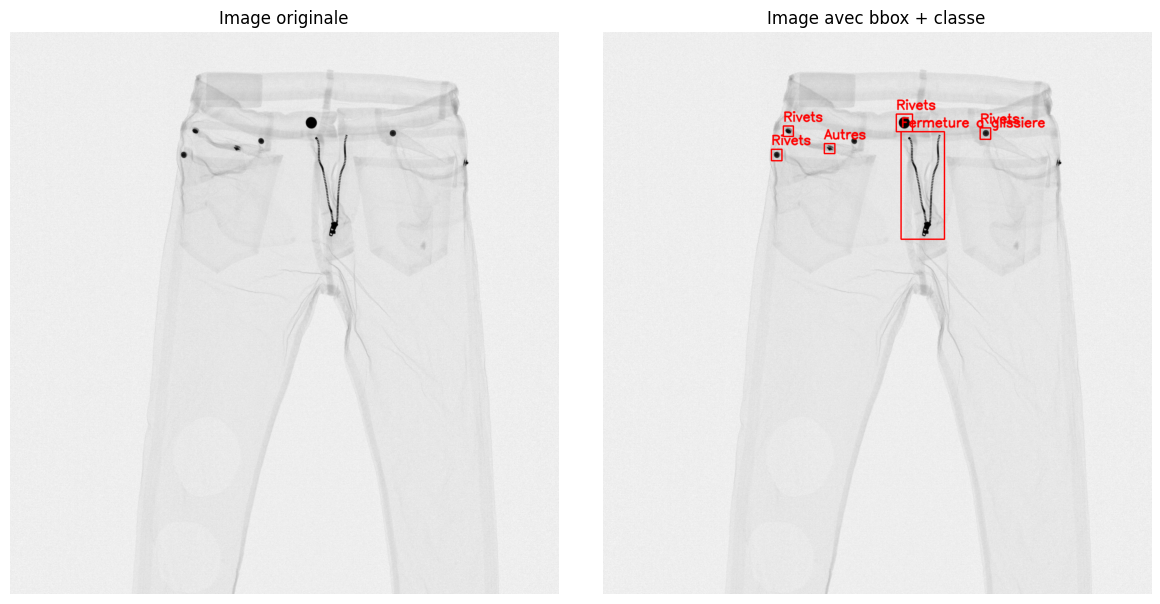


Image: Pant_test_undistorted_png_8bit\pull_ 1301.png

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1301.png: 640x640 (no detections), 9.8ms
Speed: 5.2ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


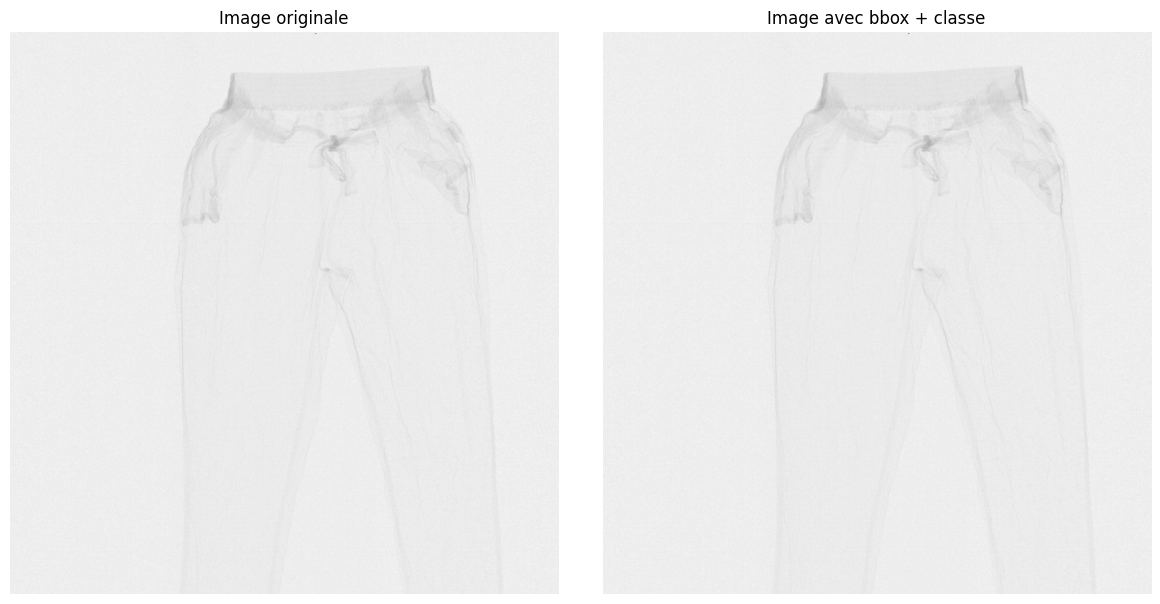


Image: Pant_test_undistorted_png_8bit\pull_ 1296.png

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_rayonX\Pant_test_undistorted_png_8bit\pull_ 1296.png: 640x640 1 bouton, 2 Rivetss, 1 Fermeture a glissiere, 13.0ms
Speed: 3.1ms preprocess, 13.0ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)
  Objet 1: bbox=(647,138,682,177), classif=Rivets
  Objet 2: bbox=(595,175,680,348), classif=Fermeture a glissiere
  Objet 3: bbox=(912,224,937,280), classif=Fermeture a glissiere
  Objet 4: bbox=(915,262,940,293), classif=Rivets


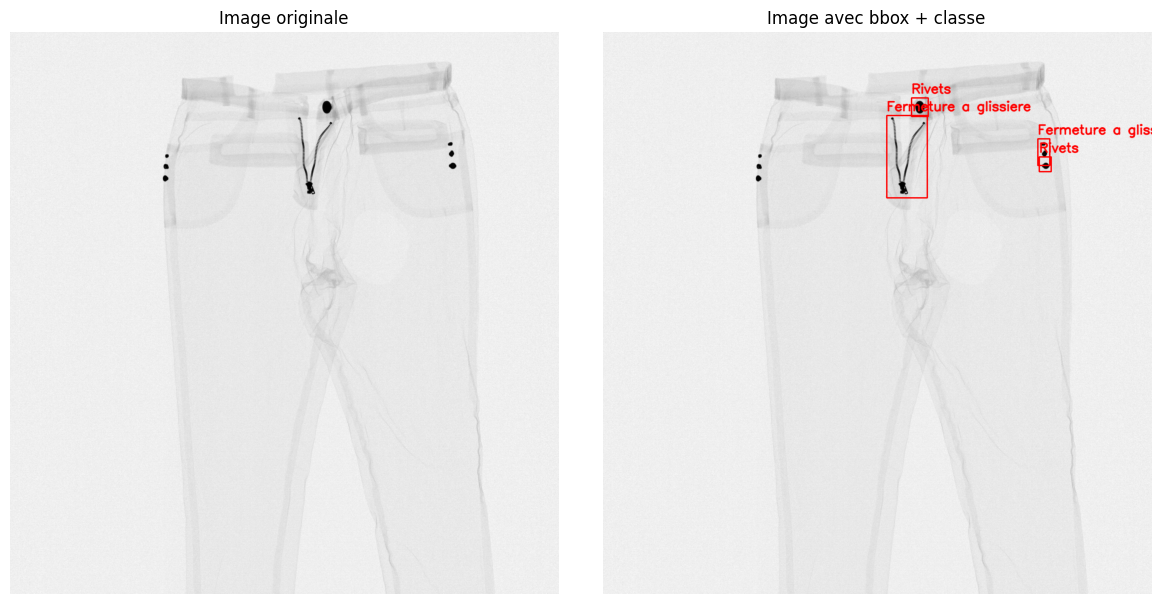

In [8]:
import os
import random
import yaml
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50
from PIL import Image
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt



class_names_list = [ 'Autres', 'Fermeture a glissiere', 'Rivets','bouton']

# Nombre de classes
num_classes = len(class_names_list)

# Charger ResNet adapté au nombre de classes
model_resnet = resnet50(pretrained=True)
model_resnet.fc = torch.nn.Linear(model_resnet.fc.in_features, num_classes)
model_resnet.load_state_dict(torch.load('resnet_pants_classifier.pth'))#############
model_resnet.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_resnet.to(device)

# Transformation pour ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Charger modèle YOLO entraîné
model_path = "runs/detect/train5/weights/best.pt"
model_yolo = YOLO(model_path)

# Dossier images
images_folder = 'Pant_test_undistorted_png_8bit'
image_files = [os.path.join(images_folder, f) for f in os.listdir(images_folder) if f.endswith('.png')]

# Choisir 3 images aléatoires
test_images = random.sample(image_files, min(3, len(image_files)))

for img_path in test_images:
    print(f"\nImage: {img_path}")
    
    # 1. Prédiction YOLO (détection)
    results = model_yolo.predict(source=img_path, conf=0.25)[0]
    
    # Charger image avec PIL et CV2
    img_pil = Image.open(img_path).convert('RGB')
    img_cv2 = cv2.imread(img_path)
    img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    
    # Copier image pour annotation
    img_annotated = img_cv2.copy()

    # Pour chaque bbox détectée, crop et classifier avec ResNet
    for i, box in enumerate(results.boxes.xyxy):  # bbox format [x1,y1,x2,y2]
        x1, y1, x2, y2 = map(int, box.tolist())
        crop_img = img_pil.crop((x1, y1, x2, y2))
        
        # Préparer l'image pour ResNet
        input_tensor = transform(crop_img).unsqueeze(0).to(device)
        
        # Prédiction ResNet
        with torch.no_grad():
            output = model_resnet(input_tensor)
            pred_class_idx = torch.argmax(output, dim=1).item()
            pred_class_name = class_names_list[pred_class_idx]
        
        print(f"  Objet {i+1}: bbox=({x1},{y1},{x2},{y2}), classif={pred_class_name}")
        
        # Dessiner bbox et texte sur l'image annotée
        cv2.rectangle(img_annotated, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=2)
        cv2.putText(img_annotated, pred_class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 
                    0.9, (255, 0, 0), 2, lineType=cv2.LINE_AA)
    
    # Afficher côte à côte : image originale | image annotée
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_cv2)
    plt.title("Image originale")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_annotated)
    plt.title("Image avec bbox + classe")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


# Detection + classification (Faster R-CNN)  

In [25]:
import os
import pandas as pd
from PIL import Image

# Chemins
images_dir = "data/images"
labels_dir = "data/labels"

data = []

for label_file in os.listdir(labels_dir):
    if not label_file.endswith(".txt"):
        continue

    image_name = label_file.replace(".txt", ".png")  
    image_path = os.path.join(images_dir, image_name)
    
    if not os.path.exists(image_path):
        print(f"Image {image_name} non trouvée.")
        continue

    # Récupérer taille de l'image
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    # Lire le fichier label
    with open(os.path.join(labels_dir, label_file), 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue

        class_id, x_center, y_center, width, height = map(float, parts)

        x_min = (x_center - width / 2) * img_width
        y_min = (y_center - height / 2) * img_height
        x_max = (x_center + width / 2) * img_width
        y_max = (y_center + height / 2) * img_height

        data.append([image_name, x_min, y_min, x_max, y_max, int(class_id)])

# Enregistrement en CSV
df = pd.DataFrame(data, columns=['image_id', 'x_min', 'y_min', 'x_max', 'y_max', 'class_id'])
df.to_csv("annotations.csv", index=False)


In [18]:
import pandas as pd

annotation = pd.read_csv("annotations.csv")
annotation.head()

,image_id,x_min,y_min,x_max,y_max,class_id
0,001_r1.png,450.429696,244.290426,467.179776,261.029910,1
1,001_r1.png,747.710208,189.850146,781.210368,224.750358,0
2,001_r1.png,562.079808,277.780452,577.439424,294.530412,1
3,001_r1.png,880.299648,208.000398,897.049728,221.960250,1
4,001_r1.png,1077.089472,228.929700,1092.439872,241.489260,1


In [24]:
import torch
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
import torchvision.transforms as T
import pandas as pd
from PIL import Image
import os

# ==== Dataset adapté ====
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, images_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.images_dir = images_dir
        self.transform = transform
        self.image_ids = self.df['image_id'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        records = self.df[self.df['image_id'] == image_id]

        img_path = os.path.join(self.images_dir, image_id)
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        boxes = records[['x_min', 'y_min', 'x_max', 'y_max']].values
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        # Décalage +1 sur class_id pour éviter les problèmes avec le background
        labels = torch.as_tensor(records['class_id'].values + 1, dtype=torch.int64)

        # On filtre les boxes invalides
        keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        boxes = boxes[keep]
        labels = labels[keep]

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        return img, target

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 — Train Loss: 1.3340 — Val Loss: 0.7440
✔ Nouveau meilleur modèle sauvegardé (val_loss: 0.7440)
Epoch 2/10 — Train Loss: 0.7574 — Val Loss: 0.6664
✔ Nouveau meilleur modèle sauvegardé (val_loss: 0.6664)
Epoch 3/10 — Train Loss: 0.6057 — Val Loss: 0.5367
✔ Nouveau meilleur modèle sauvegardé (val_loss: 0.5367)
Epoch 4/10 — Train Loss: 0.5060 — Val Loss: 0.5055
✔ Nouveau meilleur modèle sauvegardé (val_loss: 0.5055)
Epoch 5/10 — Train Loss: 0.4787 — Val Loss: 0.4629
✔ Nouveau meilleur modèle sauvegardé (val_loss: 0.4629)
Epoch 6/10 — Train Loss: 0.4499 — Val Loss: 0.5120
Epoch 7/10 — Train Loss: 0.4415 — Val Loss: 0.4761
Epoch 8/10 — Train Loss: 0.4167 — Val Loss: 0.4078
✔ Nouveau meilleur modèle sauvegardé (val_loss: 0.4078)
Epoch 9/10 — Train Loss: 0.4148 — Val Loss: 0.4146
Epoch 10/10 — Train Loss: 0.4105 — Val Loss: 0.4538


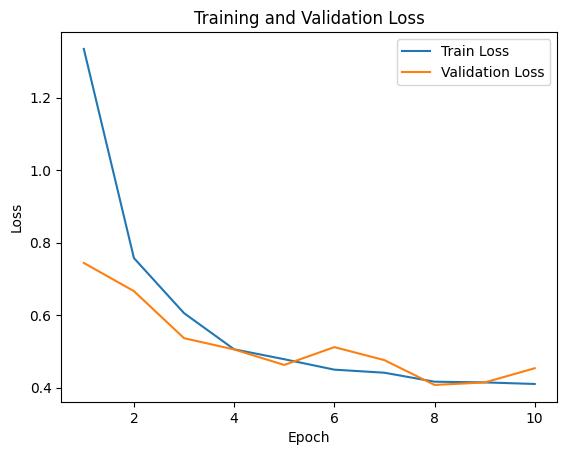

In [25]:



# ==== Transform minimal ====
transform = T.ToTensor()

# ==== Hyperparamètres ====
num_classes = 5  # NOMBRE TOTAL DE CLASSES + 1 pour le background
batch_size = 16
num_epochs = 10
learning_rate = 0.005

# ==== Dataset ====
dataset = CustomDataset("annotations.csv", "data/images", transform=transform)

# ==== Split train/val ====
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# ==== DataLoaders ====
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# ==== Modèle ====
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# ==== Optimizer ====
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=0.0005)

# ==== Fonction entraînement ====
def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    running_loss = 0
    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    return running_loss / len(data_loader)


# ==== Fonction validation ====
def evaluate(model, data_loader, device):
    model.train()  # Important : mode train obligatoire pour obtenir la loss
    running_loss = 0
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)  # Retourne bien la loss en mode train
            losses = sum(loss for loss in loss_dict.values())
            running_loss += losses.item()

    model.eval()  # On repasse en mode éval après
    return running_loss / len(data_loader)



# ==== Entraînement ====
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, train_loader, device)
    val_loss = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs} — Train Loss: {train_loss:.4f} — Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_fasterrcnn_model.pth")
        print(f"✔ Nouveau meilleur modèle sauvegardé (val_loss: {val_loss:.4f})")

# ==== Courbes de perte ====
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [34]:
# 1. Instancier le modèle (architecture identique à celle utilisée à l'entraînement)
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, num_classes=5)  
# num_classes = nombre de classes + 1 pour le fond, ici 5 classes

# 2. Charger les poids sauvegardés (state_dict)
state_dict = torch.load("best_fasterrcnn_model.pth")
model.load_state_dict(state_dict)

# 3. Mode évaluation et envoi sur device
model.eval()
model.to(device)

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_2872\2952646183.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("best_fasterrcnn_model.pth")


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

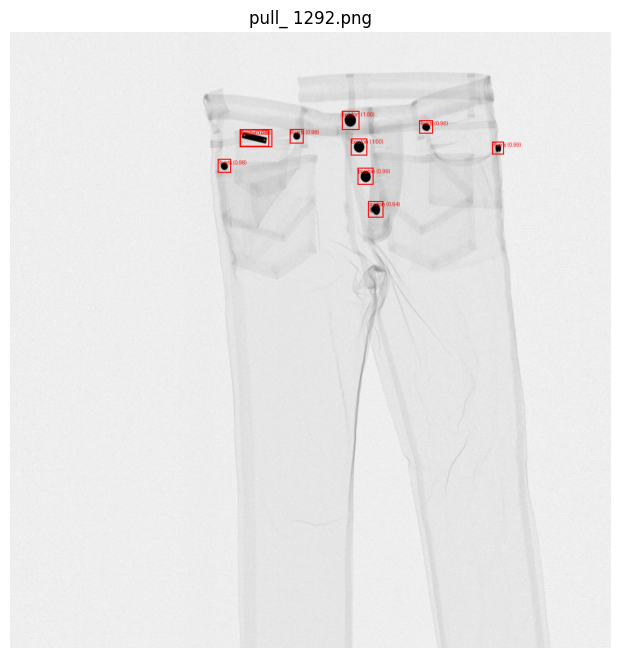

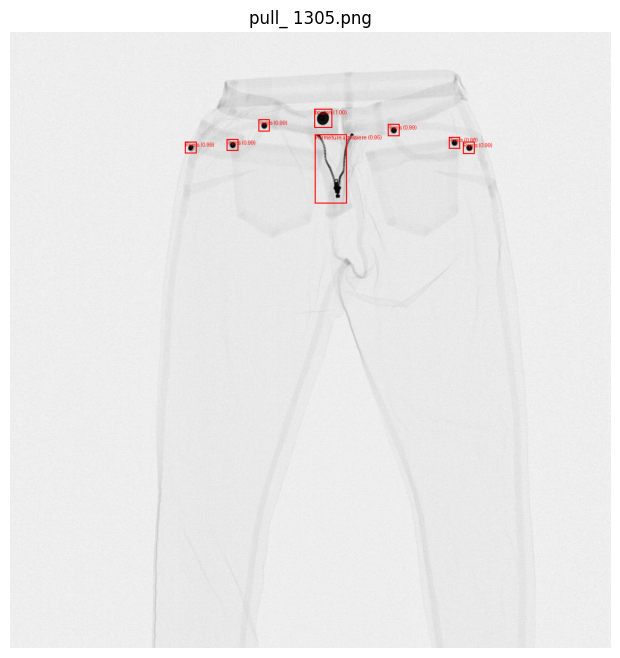

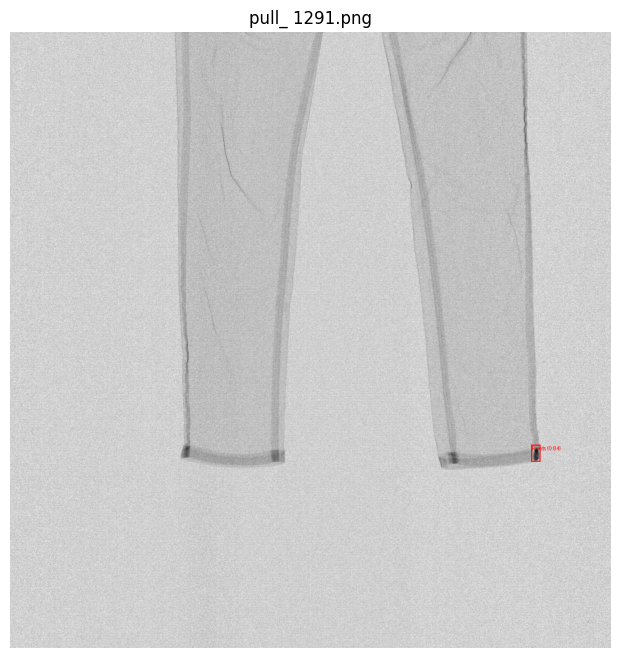

In [38]:
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from torchvision import transforms
import os
import random

# === Dictionnaire id -> nom des classes ===
id2label = {
    1: "bouton",
    2: "Rivets",
    3: "Fermeture a glissiere",
    4: "Jacron",
    5: "Autres"
}

# === Définir le device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Chemin du dossier contenant les images ===
images_dir = "Pant_test_undistorted_png_8bit"

# === Sélection aléatoire de 3 images ===
image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png'))]
selected_images = random.sample(image_files, 3)

# === Prétraitement ===
transform = transforms.Compose([
    transforms.ToTensor()
])

# === Boucle sur les 3 images sélectionnées ===
for img_name in selected_images:
    image_path = os.path.join(images_dir, img_name)
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)[0]

    threshold = 0.3
    boxes = outputs['boxes'].to("cpu")
    scores = outputs['scores'].to("cpu")
    labels = outputs['labels'].to("cpu")

    selected_indices = scores > threshold
    boxes = boxes[selected_indices]
    labels = labels[selected_indices]
    scores = scores[selected_indices]

    # Dessin
    draw = ImageDraw.Draw(image)
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        class_name = id2label.get(label.item(), "Unknown")
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        draw.text((x1, y1), f"{class_name} ({score:.2f})", fill="red")

    # Affichage
    plt.figure(figsize=(8, 8))
    plt.title(img_name)
    plt.imshow(image)
    plt.axis('off')
    plt.show()
